# Generalised Deepfake Detection using Supervised Anomaly Detection

## 1. Install Dependencies

In [1]:
!pip install torch torchvision
!pip install grad-cam
!pip install opencv-python
!pip install matplotlib
!pip install normflows

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 29.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=24df68e31f41c38d4866f3f2e04b5e6f0b0e34f7bbb645af031dd81bf5c9c6bd
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87247 sha256=0a848c75d50b0ca931c6e34c53f5b327ee53e611f1d4a580642514e21c9dcbea
  Stored in directory: /root/.cache/pip/wheels/f7/b4/37/a3acc21799a058d6fe15127321dcdf99826f438bb591accafa
Successfully built normflows


## 2. Kaggle API Setup & Dataset Download

In [2]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pranabr0y/celebdf-v2image-dataset
!unzip -q celebdf-v2image-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/pranabr0y/celebdf-v2image-dataset
License(s): other
100% 1.46G/1.46G [00:15<00:00, 102MB/s] 



## 3. Imports

In [26]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import cv2
import normflows as nf

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from PIL import Image

REAL_CLASS_IDX = 1

## 4. Dataset & DataLoader Setup

Images are resized to 224×224 to match MobileNetV2 input.

In [27]:
train_path = "/content/Celeb_V2/Train"
test_path  = "/content/Celeb_V2/Test"
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset_full = datasets.ImageFolder(train_path, transform=transform_train)
test_dataset = datasets.ImageFolder(test_path, transform=transform_test)
subset_size = 5000
real_indices = [i for i, label in enumerate(train_dataset_full.targets) if label == REAL_CLASS_IDX]
num_real_for_subset = min(subset_size, len(real_indices))
selected_real_indices = np.random.choice(real_indices, num_real_for_subset, replace=False)
train_dataset = Subset(train_dataset_full, selected_real_indices)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

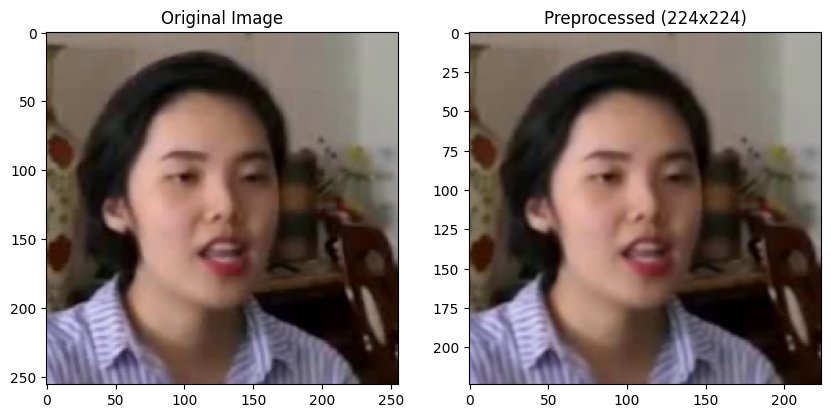

In [28]:
import matplotlib.pyplot as plt
import cv2
from PIL import Image

sample_img_path = "/content/Celeb_V2/Train/real/00000_face_0.jpg"
raw_img = cv2.imread(sample_img_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

pil_img = Image.open(sample_img_path).convert('RGB')
processed_tensor = transform_test(pil_img)
processed_img = processed_tensor.permute(1, 2, 0).numpy()
processed_img = processed_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
processed_img = np.clip(processed_img, 0, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(raw_img)
ax[0].set_title("Original Image")
ax[1].imshow(processed_img)
ax[1].set_title("Preprocessed (224x224)")
plt.show()

## 5. Feature Extraction with MobileNetV2

MobileNetV2 (pre-trained on ImageNet) is used as a feature extractor. It yields a **1280-dimensional** feature vector per image.

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

backbone = models.mobilenet_v2(pretrained=True)
feature_extractor = backbone.features.to(device).eval()

for param in feature_extractor.parameters():
    param.requires_grad = False


def extract_features(loader):
    """Extract 1280-d GAP features and labels from a DataLoader."""
    all_features, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            feats  = feature_extractor(images)
            feats  = torch.mean(feats, dim=[2, 3])
            all_features.append(feats.cpu())
            all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)


print("Extracting train features...")
train_features, train_labels = extract_features(train_loader);

print("Extracting test features...")
test_features, test_labels = extract_features(test_loader);

print(f"Train features shape: {train_features.shape}")
print(f"Test  features shape: {test_features.shape}")

Using device: cuda
Extracting train features...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Extracting test features...
Train features shape: torch.Size([5000, 1280])
Test  features shape: torch.Size([10103, 1280])


## 6. Normalizing Flow — Training on Real Images Only

A **Normalizing Flow (NF)** learns the exact density of the real-data distribution, modelled as a Multivariate Gaussian (MGD).  
- The NF is trained **only on real image features**.  
- At inference, fake images receive **low log-likelihood** scores because they lie in low-density regions of the learned distribution.  
- A threshold on log-likelihood separates real (high score) from fake (low score).  

This directly implements the *Normalising Flow models real data as MGD* approach from the notes.

In [30]:
from sklearn.decomposition import PCA
real_feats = train_features.numpy()
PCA_DIM = 128
pca = PCA(n_components=PCA_DIM, random_state=42, whiten=True)
real_feats_pca = pca.fit_transform(real_feats)
test_feats_pca = pca.transform(test_features.numpy())

In [31]:
LATENT_DIM = PCA_DIM
NUM_FLOWS = 12

base = nf.distributions.base.DiagGaussian(LATENT_DIM)

flows = []
for _ in range(NUM_FLOWS):
    flows.append(nf.flows.AffineCouplingBlock(
        nf.nets.MLP([LATENT_DIM // 2, 512, 512, LATENT_DIM], init_zeros=True)
    ))
    flows.append(nf.flows.Permute(LATENT_DIM, mode='swap'))
    flows.append(nf.flows.ActNorm(LATENT_DIM))

nf_model = nf.NormalizingFlow(q0=base, flows=flows)
nf_model = nf_model.to(device)

total_params = sum(p.numel() for p in nf_model.parameters() if p.requires_grad)
print(f"Enhanced Normalizing Flow parameters: {total_params:,}")

Enhanced Normalizing Flow parameters: 4,342,528


Epoch [ 10/100]  NLL Loss: 169.2103
Epoch [ 20/100]  NLL Loss: 150.9658
Epoch [ 30/100]  NLL Loss: 135.7222
Epoch [ 40/100]  NLL Loss: 123.8301
Epoch [ 50/100]  NLL Loss: 114.5948
Epoch [ 60/100]  NLL Loss: 106.1803
Epoch [ 70/100]  NLL Loss: 98.5808
Epoch [ 80/100]  NLL Loss: 91.3314
Epoch [ 90/100]  NLL Loss: 84.8575
Epoch [100/100]  NLL Loss: 78.0992


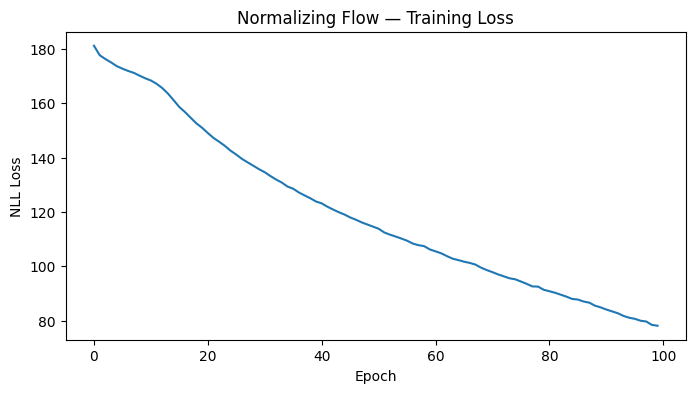

In [32]:
NF_EPOCHS = 100
NF_BATCHSIZE = 64
NF_LR = 5e-5

optimizer_nf = torch.optim.Adam(nf_model.parameters(), lr=NF_LR, weight_decay=1e-5)

real_tensor = torch.tensor(real_feats_pca, dtype=torch.float32)
nf_dataset = torch.utils.data.TensorDataset(real_tensor)
nf_loader = DataLoader(nf_dataset, batch_size=NF_BATCHSIZE, shuffle=True)

nf_model.train()
loss_history = []

for epoch in range(NF_EPOCHS):
    epoch_loss = 0.0
    for (batch,) in nf_loader:
        batch = batch.to(device)
        optimizer_nf.zero_grad()
        loss = nf_model.forward_kld(batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(nf_model.parameters(), max_norm=1.0)
        optimizer_nf.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(nf_loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{NF_EPOCHS}]  NLL Loss: {avg_loss:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NLL Loss")
plt.title("Normalizing Flow — Training Loss")
plt.show()

## 7. Inference — Log-Likelihood Thresholding

The NF assigns a **log-probability score** to each test image.  
- **High score** → image is in a high-density region → predicted **Real**  
- **Low score** → image is an out-of-distribution anomaly → predicted **Fake**  

The threshold is set at the 5th percentile of real training scores.

In [33]:
from sklearn.metrics import f1_score, accuracy_score
nf_model.eval()

def compute_log_prob(features_np):
    tensor = torch.tensor(features_np, dtype=torch.float32).to(device)
    with torch.no_grad():
        log_prob = nf_model.log_prob(tensor)
    return log_prob.cpu().numpy()

train_scores = compute_log_prob(real_feats_pca)
test_scores = compute_log_prob(test_feats_pca)
true_binary = (test_labels.numpy() == REAL_CLASS_IDX).astype(int)

valid_mask = np.isfinite(test_scores)
clean_scores = test_scores[valid_mask]
clean_labels = true_binary[valid_mask]

score_mean = np.mean(train_scores)
score_std = np.std(train_scores)

thresholds = np.linspace(clean_scores.min(), clean_scores.max(), 500)
best_f1 = 0
THRESHOLD = score_mean - 2 * score_std

for t in thresholds:
    preds = (clean_scores > t).astype(int)
    current_f1 = f1_score(clean_labels, preds)
    if current_f1 > best_f1:
        best_f1 = current_f1
        THRESHOLD = t

pred = (test_scores > THRESHOLD).astype(int)
accuracy = accuracy_score(true_binary[valid_mask], pred[valid_mask]) * 100

print(f"Optimized Threshold: {THRESHOLD:.4f}")
print(f"Best Test F1: {best_f1:.4f}")
print(f"Test Accuracy (Finite subset): {accuracy:.2f}%")

Optimized Threshold: -6393.4741
Best Test F1: 0.6653
Test Accuracy (Finite subset): 49.86%


In [34]:
print(f"Test Scores - Min: {np.min(test_scores)}, Max: {np.max(test_scores)}")
print(f"Number of NaNs in scores: {np.isnan(test_scores).sum()}")
print(f"Number of Infs in scores: {np.isinf(test_scores).sum()}")

valid_mask = np.isfinite(test_scores)
if valid_mask.any():
    valid_scores = test_scores[valid_mask]
    valid_labels = true_binary[valid_mask]

    thresholds = np.linspace(np.min(valid_scores), np.max(valid_scores), 100)
    best_f1 = 0
    THRESHOLD = thresholds[0]
    for t in thresholds:
        p = (valid_scores > t).astype(int)
        f = f1_score(valid_labels, p)
        if f > best_f1:
            best_f1 = f
            THRESHOLD = t

    pred = (test_scores > THRESHOLD).astype(int)
    accuracy = np.mean(pred == true_binary) * 100
    print(f"Fixed Threshold: {THRESHOLD:.4f}")
    print(f"New Test Accuracy: {accuracy:.2f}%")
else:
    print("Error: All test scores are non-finite. Normalizing Flow may have diverged.")

Test Scores - Min: -14514.283203125, Max: -144.48248291015625
Number of NaNs in scores: 0
Number of Infs in scores: 0
Fixed Threshold: -6385.9111
New Test Accuracy: 49.86%


## 8. Evaluation — Classification Report & Score Distribution

Classification Report:
              precision    recall  f1-score   support

        Fake       0.67      0.00      0.00      5067
        Real       0.50      1.00      0.67      5036

    accuracy                           0.50     10103
   macro avg       0.58      0.50      0.33     10103
weighted avg       0.58      0.50      0.33     10103

Confusion Matrix:
[[   2 5065]
 [   1 5035]]


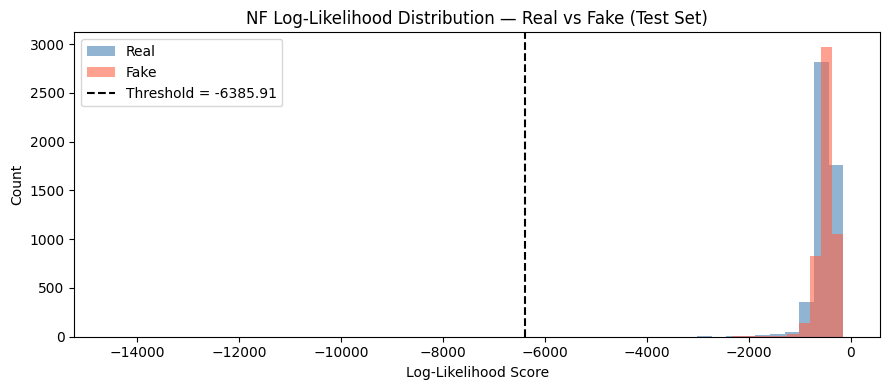

In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

print("Classification Report:")
print(classification_report(true_binary, pred, target_names=["Fake", "Real"]))

print("Confusion Matrix:")
print(confusion_matrix(true_binary, pred))

real_test_mask = (true_binary == 1) & np.isfinite(test_scores)
fake_test_mask = (true_binary == 0) & np.isfinite(test_scores)

plt.figure(figsize=(9, 4))
plt.hist(test_scores[real_test_mask], bins=50, alpha=0.6, color='steelblue', label='Real')
plt.hist(test_scores[fake_test_mask], bins=50, alpha=0.6, color='tomato', label='Fake')
if np.isfinite(THRESHOLD):
    plt.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5, label=f'Threshold = {THRESHOLD:.2f}')
plt.xlabel("Log-Likelihood Score")
plt.ylabel("Count")
plt.title("NF Log-Likelihood Distribution — Real vs Fake (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

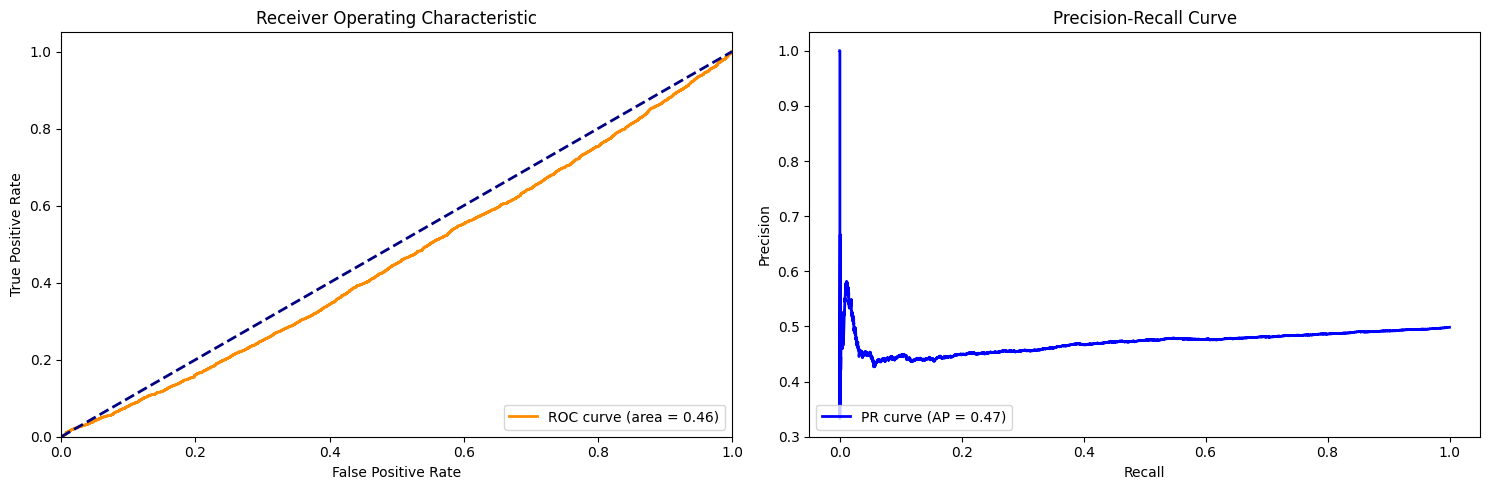

In [36]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fpr, tpr, _ = roc_curve(true_binary[valid_mask], test_scores[valid_mask])
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(true_binary[valid_mask], test_scores[valid_mask])
avg_precision = average_precision_score(true_binary[valid_mask], test_scores[valid_mask])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic')
ax[0].legend(loc='lower right')

ax[1].plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.2f})')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc='lower left')

plt.tight_layout()
plt.savefig('roc_pr_curves.png')
plt.show()

## 9. Grad-CAM Explainability

Grad-CAM is applied to the MobileNetV2 backbone (fine-tuned for 2-class classification) to visualize **which facial regions** were most informative. Heatmaps highlight areas that deviate from the real-data distribution — often compression artefacts, blending boundaries, or unnatural skin textures in deepfakes.

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

clf_model = models.mobilenet_v2(pretrained=True)
clf_model.classifier[1] = nn.Linear(clf_model.last_channel, 2)
clf_model = clf_model.to(device)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(clf_model.parameters(), lr=1e-4)
EPOCHS     = 2

clf_model.train()
for epoch in range(EPOCHS):
    running_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = clf_model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {running_loss:.4f}")

torch.save(clf_model.state_dict(), "deepfake_clf_model.pth")
print("Classifier model saved.")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/2  Loss: 7.3888
Epoch 2/2  Loss: 0.3321
Classifier model saved.


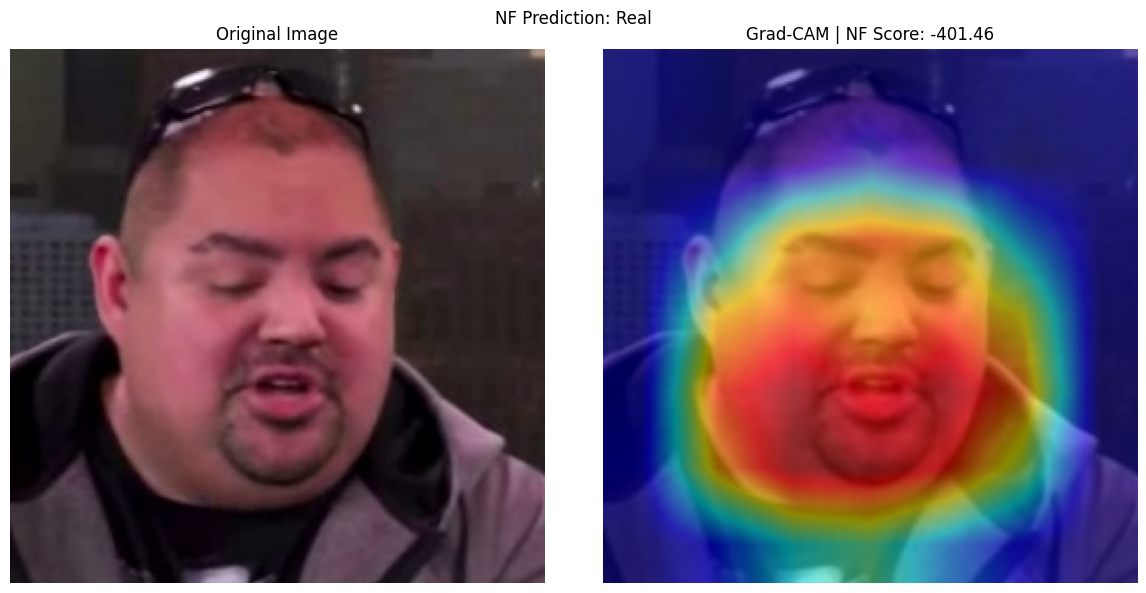

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [clf_model.features[-1]]
cam = GradCAM(model=clf_model, target_layers=target_layers)

img_path = "/content/Celeb_V2/Val/real/00007_face_431.jpg"
img = cv2.imread(img_path)
raw_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rgb_img = cv2.resize(raw_rgb, (224, 224))
normalized_rgb = np.float32(rgb_img) / 255.0

input_tensor = transform_test(Image.fromarray(rgb_img)).unsqueeze(0).to(device)

for param in target_layers[0].parameters():
    param.requires_grad = True

grayscale_cam = cam(input_tensor=input_tensor)[0]
grayscale_cam = cv2.resize(grayscale_cam, (rgb_img.shape[1], rgb_img.shape[0]))

for param in target_layers[0].parameters():
    param.requires_grad = False

visualization = show_cam_on_image(normalized_rgb, grayscale_cam, use_rgb=True)

single_feat = pca.transform(feature_extractor(input_tensor).mean(dim=[2, 3]).cpu().detach().numpy())
single_score = compute_log_prob(single_feat)[0]
nf_prediction = "Real" if single_score > THRESHOLD else "Fake (Anomaly)"

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(raw_rgb)
ax[0].set_title("Original Image")
ax[0].axis("off")

ax[1].imshow(visualization)
ax[1].set_title(f"Grad-CAM | NF Score: {single_score:.2f}")
ax[1].axis("off")

plt.suptitle(f"NF Prediction: {nf_prediction}")
plt.tight_layout()
plt.show()

## 10. Save the Normalizing Flow Model

In [40]:
import torch

torch.save(nf_model.state_dict(), "normalizing_flow_deepfake.pth")
print("Normalizing Flow model saved as 'normalizing_flow_deepfake.pth'")
print(f"\nFinal Test Accuracy: {accuracy:.2f}%")
print(f"Anomaly Threshold  : {THRESHOLD:.4f}")

Normalizing Flow model saved as 'normalizing_flow_deepfake.pth'

Final Test Accuracy: 49.86%
Anomaly Threshold  : -6385.9111


## 11. Save All Project Artifacts

In [41]:
import pickle
import joblib

np.save('train_features_pca.npy', real_feats_pca)
np.save('test_features_pca.npy', test_feats_pca)
np.save('test_labels.npy', true_binary)

joblib.dump(pca, 'pca_transformer.joblib')

torch.save(feature_extractor.state_dict(), 'mobilenet_backbone.pth')

torch.save(nf_model.state_dict(), 'normalizing_flow_model.pth')

print("Core models and data artifacts saved successfully.")

Core models and data artifacts saved successfully.


Sample image for before/after not found.
Visualizations and plots saved successfully.


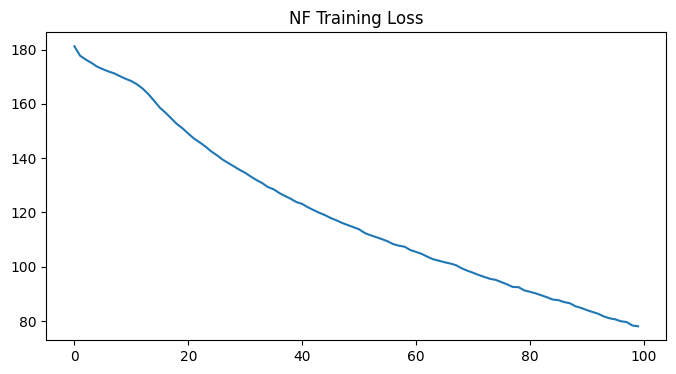

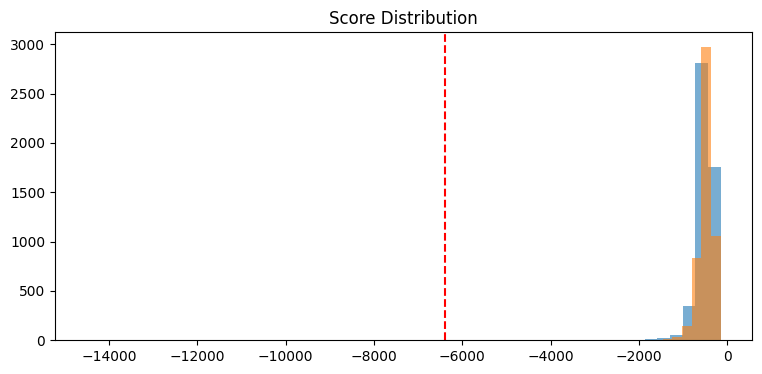

In [42]:
import matplotlib.pyplot as plt

def save_before_after(img_path):
    raw_img = cv2.imread(img_path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)


    pil_img = Image.open(img_path).convert('RGB')
    processed_tensor = transform_test(pil_img)
    processed_img = processed_tensor.permute(1, 2, 0).numpy()

    processed_img = processed_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    processed_img = np.clip(processed_img, 0, 1)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(raw_img)
    ax[0].set_title("Original Image")
    ax[1].imshow(processed_img)
    ax[1].set_title("Preprocessed (224x224)")
    plt.savefig('before_after_preprocessing.png')
    plt.show()

sample_img = "/content/Celeb_V2/Test/real/00007_face_431.jpg"
try:
    save_before_after(sample_img)
except:
    print("Sample image for before/after not found.")


plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("NF Training Loss")
plt.savefig('nf_loss_plot.png')

plt.figure(figsize=(9, 4))
plt.hist(test_scores[real_test_mask], bins=50, alpha=0.6, label='Real')
plt.hist(test_scores[fake_test_mask], bins=50, alpha=0.6, label='Fake')
plt.axvline(THRESHOLD, color='r', linestyle='--')
plt.title("Score Distribution")
plt.savefig('score_distribution.png')

print("Visualizations and plots saved successfully.")